<a href="https://colab.research.google.com/github/Arianna400/computer_vision_part1/blob/main/Homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prac 02
For this homework you will have to complete and implement the colour balancing for:
* Gray world algorithm
* Scale-by-max algorithm

You are free to use your own images. Experiment with more images and think about the effect each of the algorithms has on the resulting (balanced) image.

### Colour Balancing
In this notebook we will show different type of colour balancing making use of von Kries' hypothesis.

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 5]


In [36]:
!wget https://raw.githubusercontent.com/Arianna400/computer_vision_part1/19f462a7a445e09108051f684315ac36b8eaf60a/bild1.png
!wget -O bild2.png https://raw.githubusercontent.com/Arianna400/computer_vision_part1/59d9dc5d1cf81a69a11c4dae09e6046ec88333a6/bild2.png

--2026-05-12 18:35:58--  https://raw.githubusercontent.com/Arianna400/computer_vision_part1/19f462a7a445e09108051f684315ac36b8eaf60a/bild1.png
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1468779 (1.4M) [image/png]
Saving to: ‘bild1.png.4’

bild1.png.4         100%[===================>]   1.40M  --.-KB/s    in 0.1s    

2026-05-12 18:35:58 (10.5 MB/s) - ‘bild1.png.4’ saved [1468779/1468779]

--2026-05-12 18:35:58--  https://raw.githubusercontent.com/Arianna400/computer_vision_part1/59d9dc5d1cf81a69a11c4dae09e6046ec88333a6/bild2.png
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HT

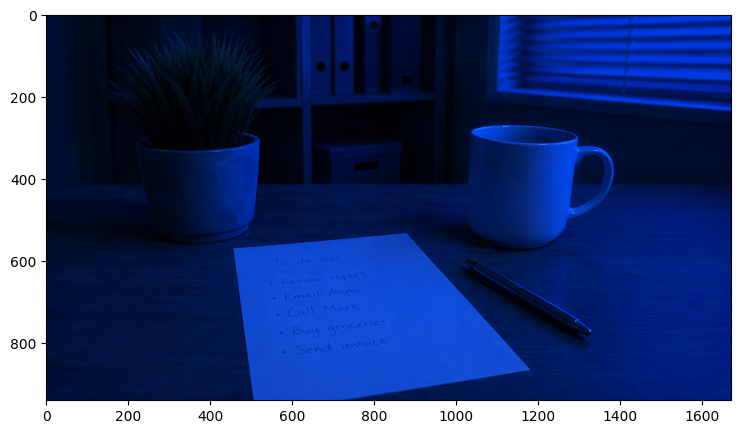

In [ ]:
img = cv2.imread('bild1.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)

### White patch
In white patch algorithm we choose a group of pixels we know they should be white. We then scale the resulting image colour channels by this white patch.

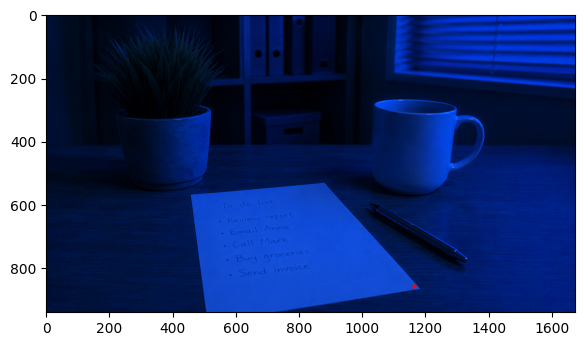

(<Axes: >, <matplotlib.image.AxesImage at 0x7d9b17e76ff0>)

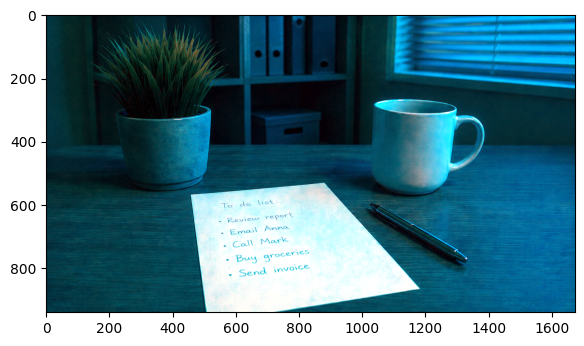

In [ ]:
# Define white patch and the coefficients
row, col = 855, 1165
white = img[row, col, :]
coeffs = 255.0/white

# Apply white balancing and generate balanced image
balanced = np.zeros_like(img, dtype=np.float32)
for channel in range(3):
    balanced[..., channel] = img[..., channel] * coeffs[channel]

# White patching does not guarantee that the dynamic range is preserved, images must be clipped.
balanced = balanced/255
balanced[balanced > 1] = 1

plt.subplot(121), plt.imshow(img)
plt.scatter(col, row, c='red', s=4)
plt.show()
plt.subplot(122), plt.imshow(balanced)

### Gray world
This algorithm assumes that a scene, on average, is gray.

(<Axes: >, <matplotlib.image.AxesImage at 0x7d9b05158140>)

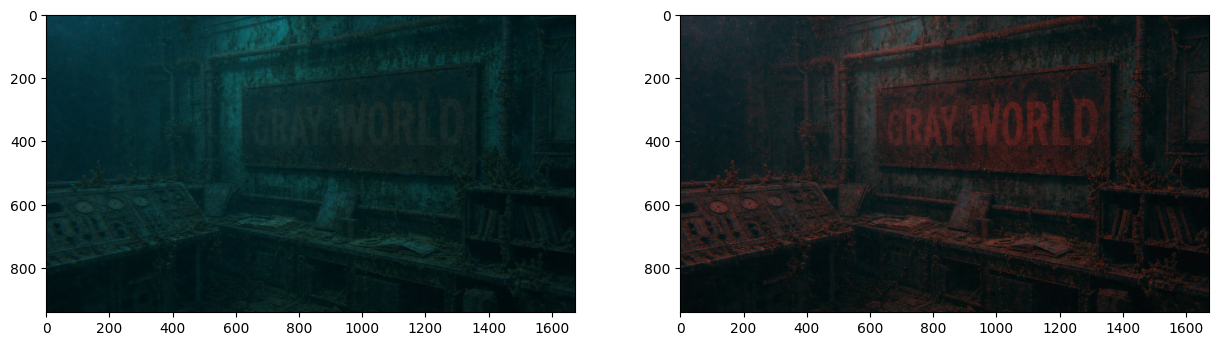

In [37]:
# Load your image
img = cv2.imread('bild2.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Compute the mean values for all three colour channels (red, green, blue)
mean_r =np.mean(img[:, :,0])
mean_g =np.mean(img[:,:, 1])
mean_b =np.mean(img[:,:,2])
mean= np.mean([mean_r, mean_g, mean_b])
# Compute the coefficients kr, kg, kb
# Note: there are 3 coefficients to compute but we only have 2 equations.
# Therefore, you have to make an assumption, fix the value of one of the
# coefficients and compute the remining two
# Hint: You can fix the coefficient of the brightest colour channel to 1.
kr =mean/ mean_r
kg =mean/ mean_g
kb =mean/mean_b

# Apply color balancing and generate the balanced image
balanced =np.clip(img * [kr, kg, kb], 0, 255).astype(np.uint8)

# Show the original and the balanced image side by side
plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(balanced)

### Scale-by-max
This is a straightforward algorithm that scales each colour channel by its maximum value. Note that it is sensitive to noise and saturations.

In [ ]:
# Load your image
img = cv2.imread('...')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Compute the maximum values for all three colour channels (red, green, blue)
max_r =
max_g =
max_b =

# Apply scale-by-max balancing and generate the balanced image
balanced =

plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(balanced)